In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
sys.path.append("..")
sys.path.append("../models")
from models.data_handler import data_wrangler
import models.modelbase.mltools as mlt
from modelbase.cascade_late_a import model_cascade2_late_a
from modelbase.cascade_mid import model_cascade2_mid
from modelbase.cascade_early import model_cascade2_early
from modelbase.vit_pyrencoder import multi_vit
from modelbase.cube_cnn import model_flat2

2024-09-10 08:16:33.840805: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [14]:
ops = [[["../models/trained/c2_early_pyramid", "cascade_early_1", "c2_early_pyramid", "c2_early"],
        ["../models/trained/mid_pyramid_lab", "cascade_late_1", "c2_mid_pyramid", "c2_mid"],
        ["../models/trained/late_pyramid_lab", "cascade_late_1", "c2_late_pyramid", "c2_late_a"],
        ["../models/trained/t1_pyramid_lab", "vit_pyramid_1", "multiscale_vit_pyramid", "multi_vit"]],
       [["../models/trained/c2_early_cube", "cascade_early_1", "c2_early_cube", "c2_early"],
        ["../models/trained/mid_cube_lab", "cascade_late_1", "c2_mid_cube", "c2_mid"],
        ["../models/trained/late_cube_lab", "cascade_late_1", "c2_late_cube", "c2_late_a"],
        ["../models/trained/t1_cube_lab", "vit_pyramid_1", "multiscale_vit_cube", "multi_vit"],
        ["../models/trained/f2_baseline_cube", "f2_baseline_1", "baseline_cube", "f2_baseline"]],
       [["../models/trained/c2_early_adjust", "cascade_early_1", "c2_early_adjust", "c2_early"],
        ["../models/trained/c2_mid_adjust", "cascade_mid_1", "c2_mid_adjust", "c2_mid"],
        ["../models/trained/c2_late_a_adjust", "cascade_late_1", "c2_late_adjust", "c2_late_a"],
        ["../models/trained/t1_adjust_lab", "vit_adjust_1", "multiscale_vit_adjust", "multi_vit"],
        ["../models/trained/f2_baseline_adjust", "f2_baseline_1", "baseline_adjust", "f2_baseline"]]]

ops = [[["../models/trained/c2_early_pyramid", "cascade_early_1", "c2_early_pyramid", "c2_early"],
        ["../models/trained/mid_pyramid_lab", "cascade_late_1", "c2_mid_pyramid", "c2_mid"]]]

print(len(ops))
print(len(ops[0]))
print(len(ops[0][0]))

data_locs = ["../data/ml_sets/pyramid_lf22/",
             "../data/ml_sets/cube_lf22/",
             "../data/ml_sets/adjust_lf22/"]

data_locs = ["../data/ml_sets/pyramid_lf22/"]

y_names = [["Water Use Efficiency", "wue"],
           ["Evaporative Stress Index", "esi"],
           ["Above Ground Biomass", "agb"]]

1
2
4


In [15]:
predictions = []
prediction_flag = True
y_actual_through = None
for datasetid in range(len(data_locs)):
    predictions.append([])
    ### load wrangler
    metadata_cols = []
    with open(data_locs[datasetid] + "info.txt", 'r') as infofile:
        metadata_total = infofile.read().replace('\n', ';')
    metadata_lines = metadata_total.split(";")
    metadata = []
    for metal in metadata_lines:
        if len(metal) > 0:
            metadata.append(metal.split(","))

    other_info = metadata.pop(0)
    other_info = {"n_folds": other_info[0], "buffer_nodata": other_info[1], "base_crs": other_info[2],
                    }
    n_layers = len(metadata)
    layer_info = {"layer_dims": [], "x_layers": [], "y_layers": [], "layer_names": []}

    for j in range(n_layers):
        layer_info["layer_dims"].append(int(metadata[j][0]))
        layer_info["layer_names"].append(metadata[j][3])
        if metadata[j][1] == "x":
            layer_info["x_layers"].append(j)
        else:
            layer_info["y_layers"].append(j)

    print("metadata check")

    wrangler = data_wrangler(data_locs[datasetid], 18, 1, layer_info["layer_dims"],
                                    1000, other_info["buffer_nodata"], layer_info["x_layers"],
                                    layer_info["y_layers"])

    wrangler.set_fold(0)

    wrangler.set_mode("val")

    ### now .. load model and compute y/yhat
    for modelid in range(len(ops[datasetid])):

        print(ops[datasetid][modelid][2])

        ### load config
        config_in = open(ops[datasetid][modelid][0] + "/" + ops[datasetid][modelid][3] + ".json")
        mc = json.load(config_in)
        mc["model_params"]["hyperparams"] = mc["model_params"]["hyperparams"] | layer_info

        print(" - loaded config")

        if ops[datasetid][modelid][3] == "multi_vit":
            working_model = multi_vit()
        if ops[datasetid][modelid][3] == "f2_baseline":
            working_model = model_flat2()
        if ops[datasetid][modelid][3] == "c2_early":
            working_model = model_cascade2_early()
        if ops[datasetid][modelid][3] == "c2_mid":
            working_model = model_cascade2_mid()
        if ops[datasetid][modelid][3] == "c2_late_a":
            working_model = model_cascade2_late_a()
        working_model.setup(mc["model_params"]["hyperparams"], mc["model_params"]["model_dir"], mc["model_params"]["model_name"],
                            0, mc["run_params"]["train_params"]["callbacks"])

        working_model.modeldir = ops[datasetid][modelid][0]

        print(" - setup model")
        working_model.load()
        print(" - loaded weights")
        y_actual, y_predicted = working_model.predict(wrangler)
        print(" - made predictions")
        y_actual_through = y_actual
        predictions[datasetid].append(y_predicted)
        



metadata check
c2_early_pyramid
 - loaded config
 - setup model
 - loaded weights
shape sanity check 0 - (13800, 15, 15) (13800, 15, 15)
shape sanity check 1 - (13800, 15, 15) (13800, 15, 15)
shape sanity check 2 - (13800, 1, 1) (13800, 1, 1)
 - made predictions
c2_mid_pyramid
 - loaded config
 - setup model
 - loaded weights
shape sanity check 0 - (13800, 15, 15) (13800, 15, 15)
shape sanity check 1 - (13800, 15, 15) (13800, 15, 15)
shape sanity check 2 - (13800, 1, 1) (13800, 1, 1)
 - made predictions


4.97497659485084
3.1209028176145273
2.271841606536499
4.97497659485084


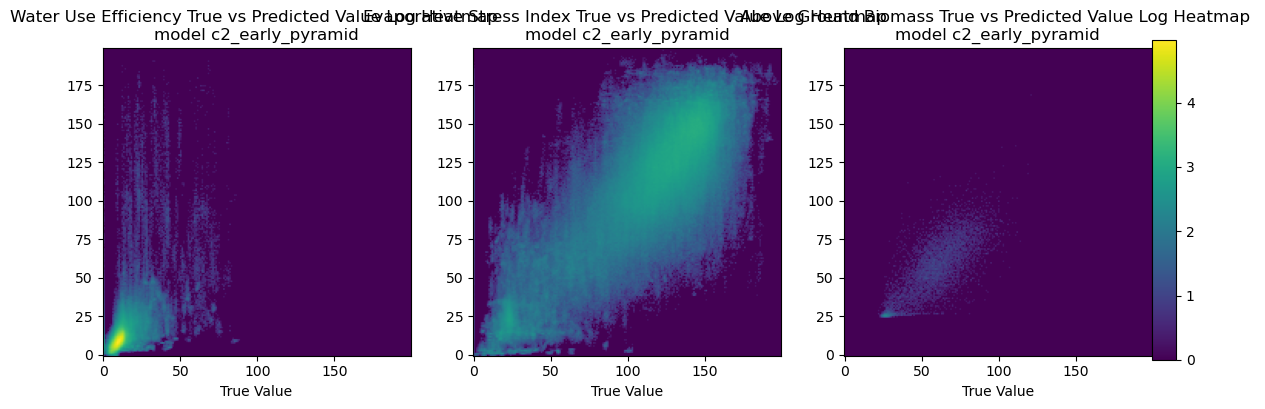

4.869472275714971
3.1212314551496214
2.3909351071033793
4.869472275714971


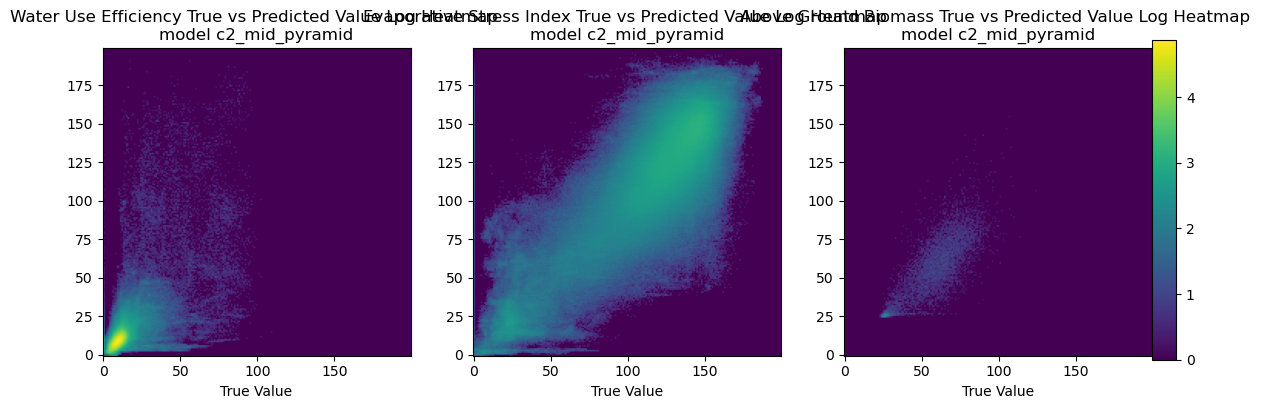

'\n        binned_y = []\n        for i in range(len(y_names)):\n            pass\n        \n        \n        for i in range(len(y_names)):\n            pass\n\n        for i in range(len(y_names)):\n            ### plot...\n            fig, ax = plt.subplots()\n            im2 = ax.hist2d(y_actual[i].flatten(), y_predicted[i].flatten(), bins=200, norm="log", range=[[0, 1], [0, 1]])\n            ax.figure.colorbar(im2[3], ax=ax)\n            ax.set(xlabel="True Value", ylabel="Predicted Value", title=y_names[i][0] + " True vs Predicted Value Log Heatmap (" + ops[datasetid][modelid][2] + ")")\n            plt.savefig("predicted_actual_heatmaps/" + ops[datasetid][modelid][2] + "_" + y_names[i][1] + "_log.png")\n\n            plt.clf()\n        print(" - done with model")'

In [86]:
for i in range(len(predictions)):
    for j in range(len(predictions[i])):
        fig, axes = plt.subplots(1, len(y_names), figsize=(12, 4))
        binned_y = []
        hist_y = []
        maxid = 0
        maxval = 0
        for k in range(len(y_names)):
            tempk = np.histogram2d(y_actual_through[k].flatten(), predictions[i][j][k].flatten(), bins=200, range=[[0, 1], [0, 1]])[0]
            tempk[tempk == 0] = 1
            tempk = np.log10(tempk)
            hist_y.append(tempk)
            tempmax = np.max(tempk)
            print(tempmax) 
            if tempmax > maxval:
                maxid = k
                maxval = tempmax

        print(maxval)
        
        for k in range(len(y_names)):
            binned_y.append(axes[k].imshow(hist_y[k], vmin=0, vmax=maxval, origin='lower'))
            #binned_y.append(axes[k].hist2d(y_actual_through[k].flatten(), predictions[i][j][k].flatten(), bins=200, norm="log", range=[[0, 1], [0, 1]]))
            axes[k].set(xlabel="True Value", title=y_names[k][0] + " True vs Predicted Value Log Heatmap \nmodel " + ops[i][j][2])
        
        fig.subplots_adjust(right=1)
        cbar_ax = fig.add_axes([1, 0.01, 0.02, 0.8])
        fig.colorbar(binned_y[maxid], cax=cbar_ax)
        plt.savefig("predicted_actual_heatmaps/" + ops[i][j][2] + "_log.png")
        plt.show()
        print(" - done with model")